# 0. Импорт и конфигурация

In [ ]:
RANDOM_STATE = 42

import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler
from typing import Iterable, Tuple, Callable
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

def set_global_seed(seed: int = RANDOM_STATE) -> None:
    np.random.seed(seed)

set_global_seed(RANDOM_STATE)

In [ ]:
import resource
soft, hard = resource.getrlimit(resource.RLIMIT_AS)
resource.setrlimit(resource.RLIMIT_AS, (10 * 1024 ** 3, hard))

# 1. Обработка данных

## Шаг 1. Считать данные

In [ ]:
Student_ID = 36

In [4]:
datasets = [
    (
        'Give Me Some Credit',
        'https://www.kaggle.com/competitions/GiveMeSomeCredit/overview',
        'SeriousDlqin2yrs'
    ),
    (
        'Porto Seguro’s Safe Driver Prediction',
        'https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/overview',
        'target'
    ),
    (
        'Statlog (Shuttle)',
        'https://archive.ics.uci.edu/dataset/148/statlog+shuttle',
        'class'
    ),
    (
        'HTRU2',
        'https://archive.ics.uci.edu/dataset/372/htru2',
        'class'
    ),
    (
        'Bank Marketing',
        'https://archive.ics.uci.edu/dataset/222/bank%2Bmarketing',
        'y'
    ),
]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Информация о датасете '{datasets[dataset_id][0]}' доступна по следующей ссылке: {datasets[dataset_id][1]}")
    print(f"Целевая переменная: {datasets[dataset_id][2]}")

Информация о датасете 'Porto Seguro’s Safe Driver Prediction' доступна по следующей ссылке: https://www.kaggle.com/competitions/porto-seguro-safe-driver-prediction/overview
Целевая переменная: target


Загрузите данные и считайте их в датафрейм

In [5]:
file_id = '1H3L6kuUg9OUVeXwb_zqsGTj3eP-7ML9T'
file_url = f'https://drive.google.com/uc?id={file_id}'
gdown.download(file_url, 'data.csv', quiet=False)

df = pd.read_csv('data.csv')
df.info()

Downloading...
From (original): https://drive.google.com/uc?id=1H3L6kuUg9OUVeXwb_zqsGTj3eP-7ML9T
From (redirected): https://drive.google.com/uc?id=1H3L6kuUg9OUVeXwb_zqsGTj3eP-7ML9T&confirm=t&uuid=24757fcb-7511-4360-bd1e-a32908959f87
To: /home/ns/Desktop/ML/ml-lab3-n-sukhov/data.csv
100%|██████████| 116M/116M [00:06<00:00, 18.0MB/s] 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

## Шаг 2. Обработка данных

В обработке датасета вы имеете (почти) полную свободу (важно в итоге просто побить бейзлайн).

Что НЕОБХОДИМО сделать:
- обработать пропуски, если есть
- закодировать категориальные фичи

Что ПОЛЕЗНО сделать:
- удалить дубликаты, если есть
- обработать выбросы
- удалить лишние фичи, если есть (возможно, полезно будет посмотреть на корреляции числовых признаков)
- стандартизировать данные

ВАЖНО: обработанный по необходимым пунктам датафрейм запишите в переменную df_base, обработанный далее по вашему желанию датафрейм запишите в переменную df_processed.

НЕ ПЕРЕЗАПИСЫВАЙТЕ ЭТИ ПЕРЕМЕННЫЕ И df, иначе могут возникнуть проблемы с прохождением тестов

In [6]:
df_base = df.copy()
df_base = df_base.replace(-1, np.nan)
df_base.isna().sum()

id                     0
target                 0
ps_ind_01              0
ps_ind_02_cat        216
ps_ind_03              0
ps_ind_04_cat         83
ps_ind_05_cat       5809
ps_ind_06_bin          0
ps_ind_07_bin          0
ps_ind_08_bin          0
ps_ind_09_bin          0
ps_ind_10_bin          0
ps_ind_11_bin          0
ps_ind_12_bin          0
ps_ind_13_bin          0
ps_ind_14              0
ps_ind_15              0
ps_ind_16_bin          0
ps_ind_17_bin          0
ps_ind_18_bin          0
ps_reg_01              0
ps_reg_02              0
ps_reg_03         107772
ps_car_01_cat        107
ps_car_02_cat          5
ps_car_03_cat     411231
ps_car_04_cat          0
ps_car_05_cat     266551
ps_car_06_cat          0
ps_car_07_cat      11489
ps_car_08_cat          0
ps_car_09_cat        569
ps_car_10_cat          0
ps_car_11_cat          0
ps_car_11              5
ps_car_12              1
ps_car_13              0
ps_car_14          42620
ps_car_15              0
ps_calc_01             0


In [7]:
bin_cols = [col for col in df_base.columns if '_bin' in col]
for col in bin_cols:
    mode_val = df_base[col].mode()[0]
    df_base[col] = df_base[col].fillna(mode_val)

cat_cols = [col for col in df_base.columns if '_cat' in col]
for col in cat_cols:
    mode_val = df_base[col].mode()[0]
    df_base[col] = df_base[col].fillna(mode_val)

numeric_cols = [col for col in df.columns if col not in ['id', 'target'] 
                and '_bin' not in col and '_cat' not in col]
for col in numeric_cols:
    median_val = df_base[col].median()
    df_base[col] = df_base[col].fillna(median_val)

In [8]:
df_base.isna().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


In [9]:
df_processed = df_base.drop_duplicates()

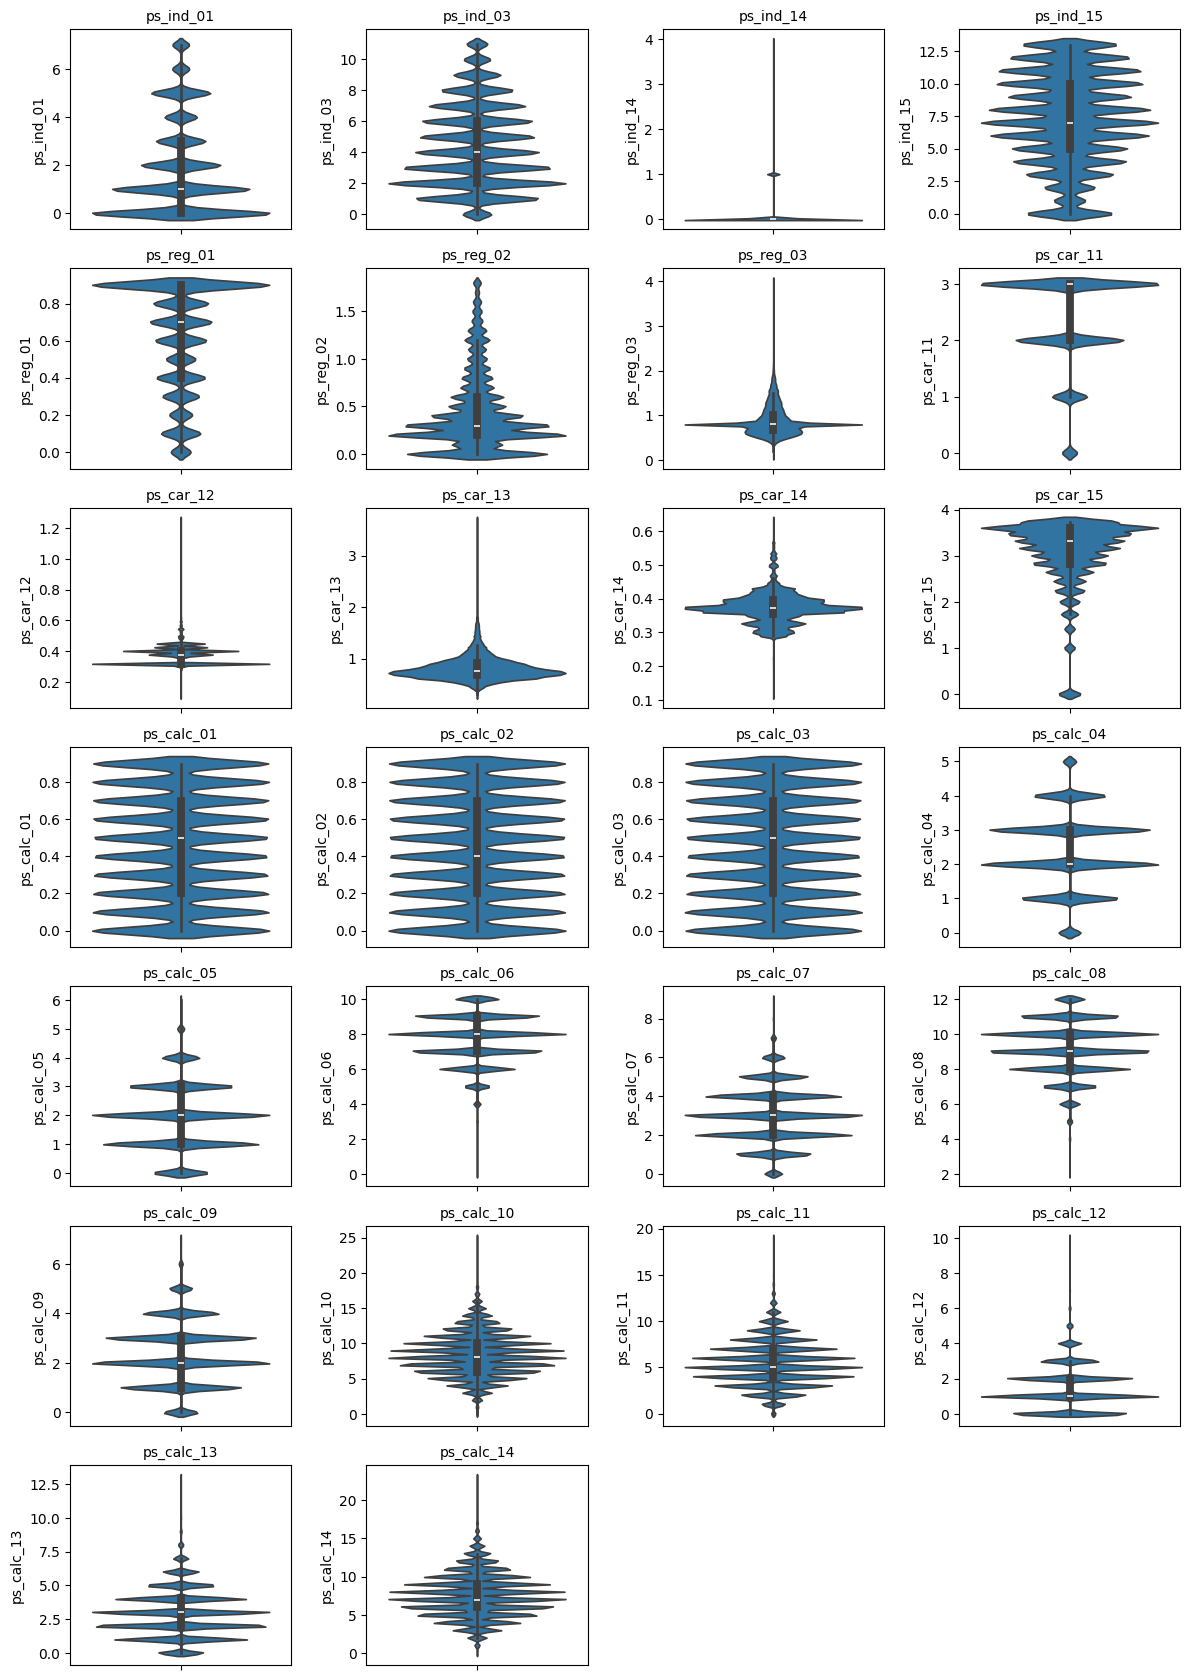

In [10]:
fig, axes = plt.subplots(15, 4, figsize=(12, 36))
axes = axes.ravel()

plot_cols = [col for col in df_processed.columns 
                   if col != 'target' and '_bin' not in col and '_cat' not in col and col != 'id']

for i, col in enumerate(plot_cols):
    if i < len(axes):
        sns.violinplot(data=df_processed, y=col, ax=axes[i])
        axes[i].set_title(f'{col}', fontsize=10)

for i in range(len(plot_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

<Axes: >

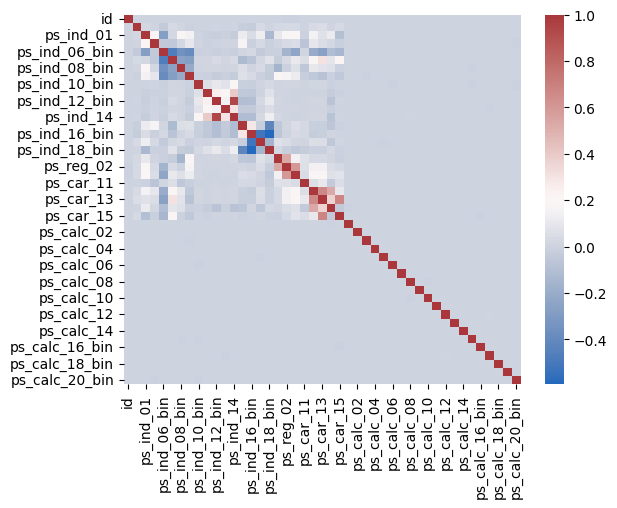

In [11]:
corrs = df_processed[[col for col in df_processed.columns if '_cat' not in col]].corr(method="spearman")
sns.heatmap(corrs, cmap="vlag")

In [12]:
df_processed = df_processed.drop(columns=["ps_ind_14"])
X = df_processed.drop(columns=["target"])
scaler_X = StandardScaler()
X_scaled = pd.DataFrame(scaler_X.fit_transform(X), columns=X.columns, index=X.index)
df_processed = pd.concat([X_scaled, df_processed['target']], axis=1)

## Шаг 3. Разделение на train/val/test


Разделите датафрейм на фичи и на целевую переменную.

In [13]:
X_base, y_base = df_base.drop(columns="target"), df_base["target"]
X_processed, y_processed = df_processed.drop(columns="target"), df_processed["target"]

Разделите датафреймы base и processed каждый на выборки train/val/test (запишите их в переменные ниже)

In [14]:
X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(X_base, y_base, test_size=0.2)

In [15]:
X_train_processed, X_test_processed, y_train_processed, y_test_processed = \
    train_test_split(X_processed, y_processed, test_size=0.2)

## Дополнительное задание*. Решение дисбаланса классов

Изучите ваш датасет на наличие дисбаланса классов. Постройте распределение классов таргет переменной.
Визуализируйте расположение классов через PCA.

Выберите стратегию, по которой будете компенсировать дисбаланс (undersampling, oversampling, интерполяция, генерация новых примеров). 
Подсказка: воспользуйтесь библиотекой `imblearn`.
Постройте визуализацию для сбалансированного датасета.

Рекомендуется далее в задании 3 сравнить различные модели на устойчивость к дисбалансу классов. Визуализация в любом виде приветствуется.

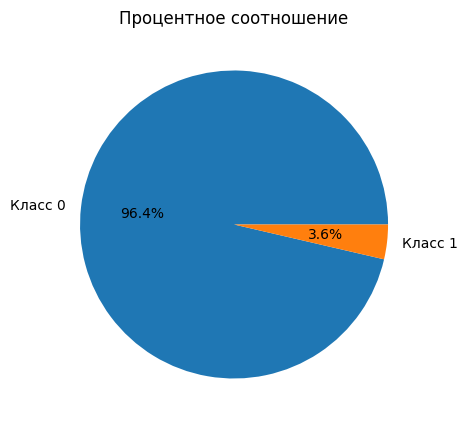

In [16]:
class_distribution = y_train_processed.value_counts()

plt.figure(figsize=(15, 5))

plt.pie(class_distribution, labels=['Класс 0', 'Класс 1'], autopct='%1.1f%%')
plt.title('Процентное соотношение')
plt.show()

In [17]:
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_train_processed)
print(pca.explained_variance_ratio_)

[0.06650928 0.04081237 0.03669421 0.03310736 0.03078105 0.02700377
 0.02471687 0.02393235 0.02126391 0.02108559 0.01915974 0.01850008
 0.01822068 0.0177442  0.01770146 0.01767128 0.01765168 0.01763991
 0.01763457 0.01762521]


Как видим, в данном датасете распределение данных равномерное, и не получается выделить 2-3 главные компоненты, описывающих выборку хотя бы на 50%.

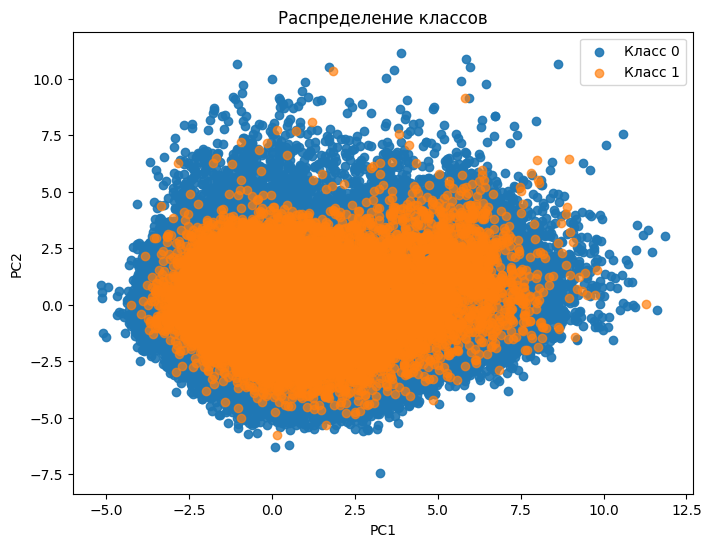

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[y_train_processed == 0, 0], X_pca[y_train_processed == 0, 1], label='Класс 0', alpha=0.9)
plt.scatter(X_pca[y_train_processed == 1, 0], X_pca[y_train_processed == 1, 1], label='Класс 1', alpha=0.7)
plt.title('Распределение классов')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [19]:
rus = RandomUnderSampler(sampling_strategy='auto')

X_resampled, y_resampled = rus.fit_resample(X_train_processed, y_train_processed)

print(y_resampled.value_counts())

X_res_pca = pca.fit_transform(X_resampled)
print(pca.explained_variance_ratio_)

target
0    17290
1    17290
Name: count, dtype: int64
[0.07245414 0.04066101 0.03819427 0.03339899 0.02945641 0.02897563
 0.02762162 0.02407583 0.02222555 0.02102509 0.0204787  0.01967574
 0.01873277 0.01820015 0.01794948 0.0175752  0.01748742 0.0174067
 0.01730443 0.01718652]


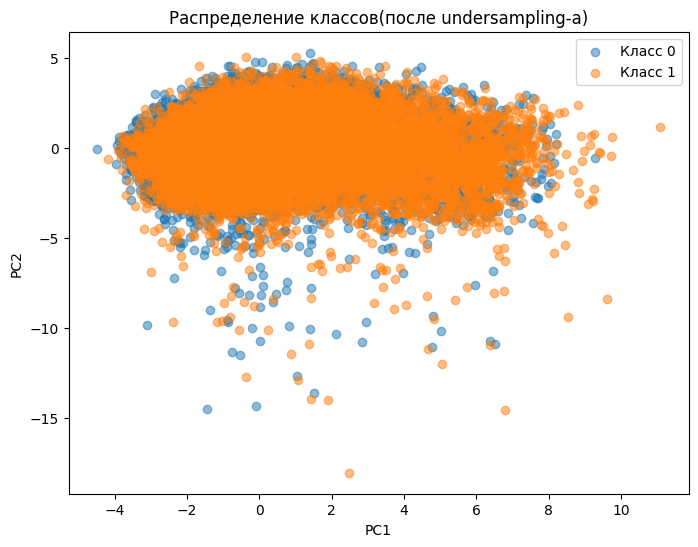

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(X_res_pca[y_resampled == 0, 0], X_res_pca[y_resampled == 0, 1], label='Класс 0', alpha=0.5)
plt.scatter(X_res_pca[y_resampled == 1, 0], X_res_pca[y_resampled == 1, 1], label='Класс 1', alpha=0.5)
plt.title('Распределение классов(после undersampling-а)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [21]:
X_train_processed, y_train_processed = X_resampled, y_resampled
X_train_processed1, X_val_processed, y_train_processed1, y_val_processed = \
    train_test_split(X_train_processed, y_train_processed, test_size=0.2)

# 2. Реализация метрик

Реализуйте метрики классификации с помощью `numpy`/`pandas`. В этом разделе запрещено использовать `sklearn.metrics`.

In [22]:
def check_lengths(func: Callable[[Iterable[int], Iterable[int]], float]) -> Callable[[Iterable[int], Iterable[int]], float]:
    def wrapper(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        if len(y_true) != len(y_pred):
            raise ValueError("y_true and y_pred must have the same length!")
        return func(y_true, y_pred)
    return wrapper

In [23]:
@check_lengths
def accuracy_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    return np.sum(y_true == y_pred) / len(y_pred) if len(y_pred) else 0

In [24]:
@check_lengths
def precision_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    return TP / (TP + FP) if (TP + FP) else 0

In [25]:
@check_lengths
def recall_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP / (TP + FN) if (TP + FN) else 0

In [26]:
def f1_manual(y_true: Iterable[int], y_pred: Iterable[int]) -> float:
    precision = precision_manual(y_true, y_pred)
    recall = recall_manual(y_true, y_pred)
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0

In [27]:
def precision_recall_curve_manual(y_true: Iterable[int], y_score: Iterable[float]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    
    thresholds = np.unique(y_score)
    thresholds = np.sort(thresholds)[::-1]
    
    precision_list = []
    recall_list = []
    
    precision_list.append(1)
    recall_list.append(0)
    
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        
        TP = np.sum((y_true == 1) & (y_pred == 1))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 1.0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        
        precision_list.append(precision)
        recall_list.append(recall)
    
    return np.array(precision_list), np.array(recall_list), np.array(thresholds)

In [28]:
def roc_curve_manual(y_true: Iterable[int], y_score: Iterable[float]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    y_true = np.array(y_true)
    y_score = np.array(y_score)
    
    thresholds = np.unique(y_score)
    thresholds = np.sort(thresholds)[::-1]
    thresholds = np.append(thresholds, thresholds[-1] - 1)
    
    fpr_list = []
    tpr_list = []

    tpr_list.append(0)
    fpr_list.append(0)
    
    for threshold in thresholds:
        y_pred = (y_score >= threshold).astype(int)
        
        TP = np.sum((y_true == 1) & (y_pred == 1))
        FP = np.sum((y_true == 0) & (y_pred == 1))
        TN = np.sum((y_true == 0) & (y_pred == 0))
        FN = np.sum((y_true == 1) & (y_pred == 0))
        
        TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
        FPR = FP / (FP + TN) if (FP + TN) > 0 else 0
        
        tpr_list.append(TPR)
        fpr_list.append(FPR)
    
    return np.array(fpr_list), np.array(tpr_list), thresholds


In [29]:
def roc_auc_manual(fpr: Iterable[float], tpr: Iterable[float]) -> float:
    fpr = np.array(fpr)
    tpr = np.array(tpr)
    
    sorted_indices = np.argsort(fpr)
    fpr_sorted = fpr[sorted_indices]
    tpr_sorted = tpr[sorted_indices]
    
    auc = 0.0
    for i in range(1, len(fpr_sorted)):
        width = fpr_sorted[i] - fpr_sorted[i-1]
        avg_height = (tpr_sorted[i] + tpr_sorted[i-1]) / 2
        auc += width * avg_height
    
    return auc

# 3. Классификация (sklearn)

Обучите различные алгоритмы классификации и сравните их между собой. В качестве baseline используйте логистическую регрессию.

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [ ]:
def apply_metrics(y_pred, y_true, y_pred_prob, name):
    print(f"{name}:")
    print(f"Accuracy: {accuracy_manual(y_true, y_pred):.4f}")
    print(f"Precision: {precision_manual(y_true, y_pred):.4f}")
    print(f"Recall: {recall_manual(y_true, y_pred):.4f}")
    print(f"F1-score: {f1_manual(y_true, y_pred):.4f}")
    precision, recall, _ = precision_recall_curve_manual(y_true, y_pred_prob)
    fpr, tpr, _ = roc_curve_manual(y_true, y_pred_prob)
    roc_auc = roc_auc_manual(fpr, tpr)
    print(f"ROC-AUC: {roc_auc:.4f}")

    fig, axis = plt.subplots(1, 2, figsize=(12, 6))

    axis[0].plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
    axis[0].plot([0, 1], [0, 1], color="red", linestyle='--')
    axis[0].set_title("ROC")
    axis[0].set_xlabel("False Positive Rate")
    axis[0].set_ylabel("True Positive Rate")
    axis[0].grid(True)

    axis[1].plot(recall, precision)
    axis[1].set_title("Precision-Recall")
    axis[1].set_xlabel("Recall")
    axis[1].set_ylabel("Precision")
    axis[1].grid(True)

    plt.tight_layout()
    plt.show()

## Шаг 1. Бейзлайн

/home/ns/ros2_venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline:
Accuracy: 0.9632
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
ROC-AUC: 0.5157


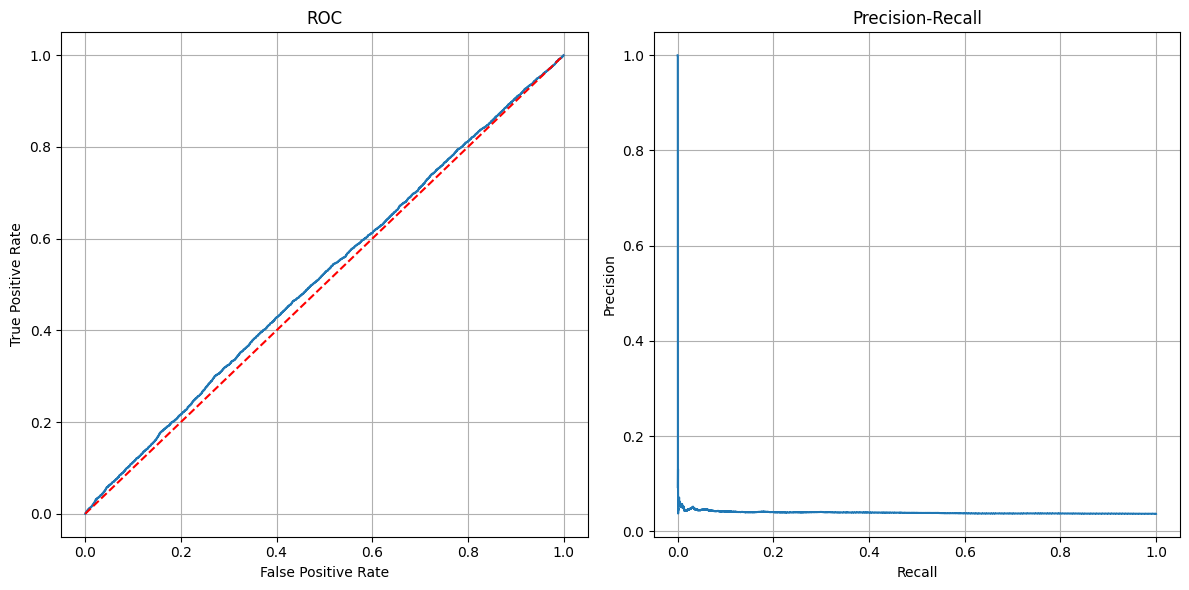

In [32]:
logreg = LogisticRegression()
logreg.fit(X_train_base, y_train_base)
y_pred_base = logreg.predict(X_test_base)
y_pred_prob_base = logreg.predict_proba(X_test_base)[:, 1]
apply_metrics(y_pred_base, y_test_base, y_pred_prob_base, "Baseline")

## Шаг 2. KNN

Воспользуйтесь `sklearn.neighbors import KNeighborsClassifier`. Сравните с бейзлайном. 

KNN:
Accuracy: 0.6616
Precision: 0.0486
Recall: 0.4382
F1-score: 0.0874
ROC-AUC: 0.5767


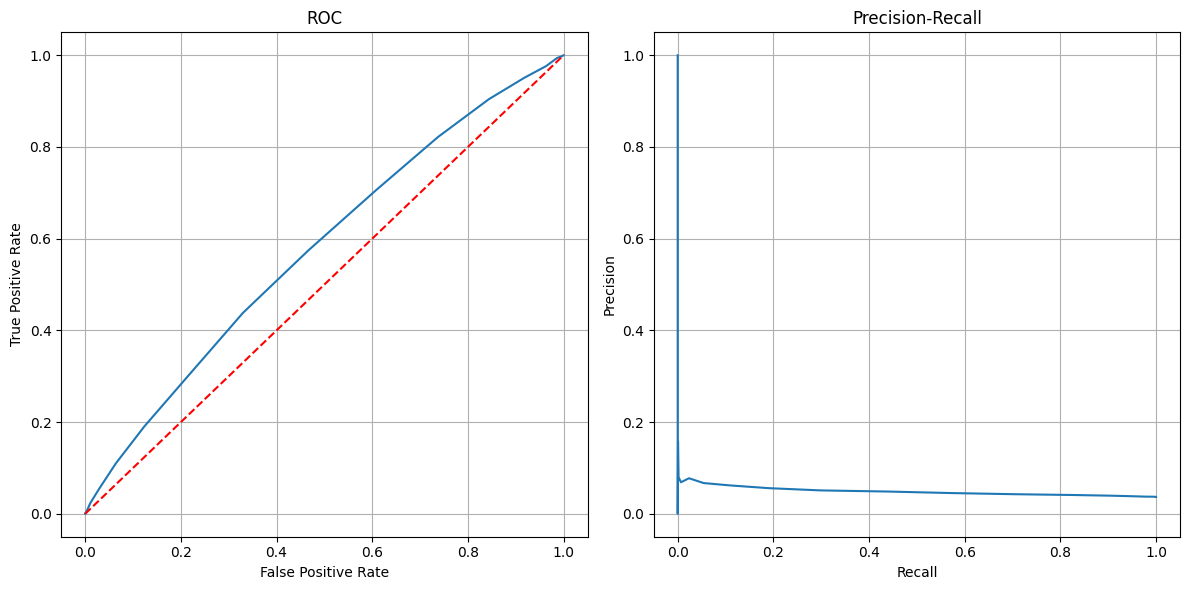

In [33]:
knn = KNeighborsClassifier(n_neighbors=20, n_jobs=-1)
knn.fit(X_train_processed, y_train_processed)

y_pred_knn = knn.predict(X_test_processed)
y_pred_prob_knn = knn.predict_proba(X_test_processed)[:, 1]

apply_metrics(y_pred_knn, y_test_processed, y_pred_prob_knn, "KNN")

## Шаг 3. Решающее дерево

Воспользуйтесь `sklearn.tree import DecisionTreeClassifier`. Сравните с бейзлайном. 

Decision Tree:
Accuracy: 0.5240
Precision: 0.0399
Recall: 0.5143
F1-score: 0.0740
ROC-AUC: 0.5193


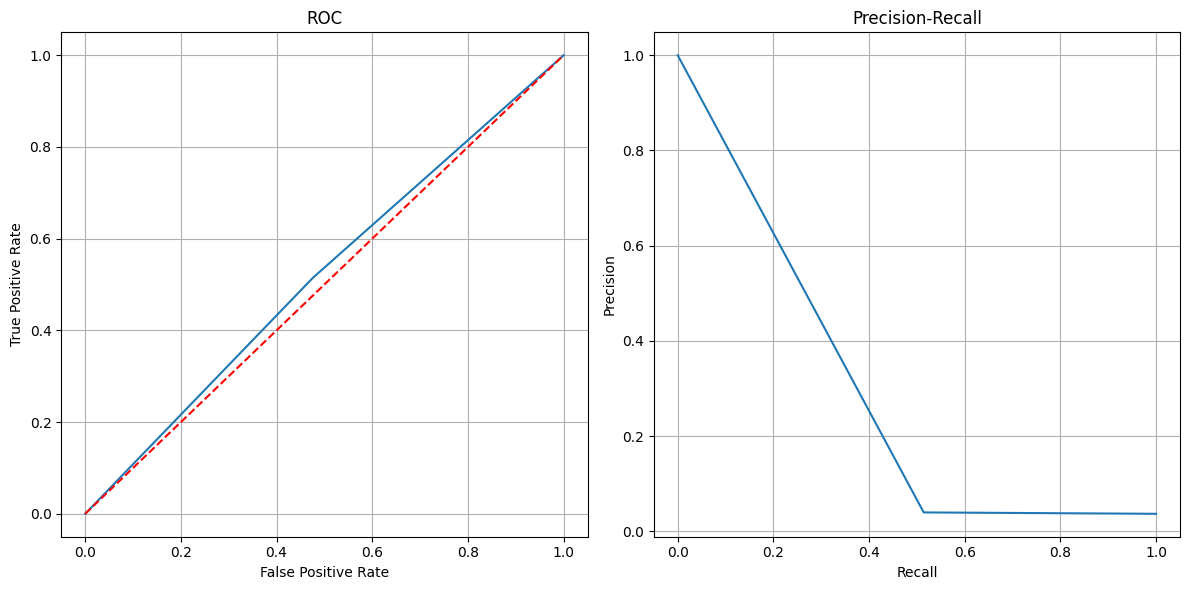

In [34]:
dt = DecisionTreeClassifier()
dt.fit(X_train_processed, y_train_processed)

y_pred_dt = dt.predict(X_test_processed)
y_pred_prob_dt = dt.predict_proba(X_test_processed)[:, 1]

apply_metrics(y_pred_dt, y_test_processed, y_pred_prob_dt, "Decision Tree")

## Шаг 4. Случайный лес

Воспользуйтесь `sklearn.ensemble import RandomForestClassifier`. Сравните с бейзлайном. 

Random Forest:
Accuracy: 0.5881
Precision: 0.0534
Recall: 0.6060
F1-score: 0.0982
ROC-AUC: 0.6310


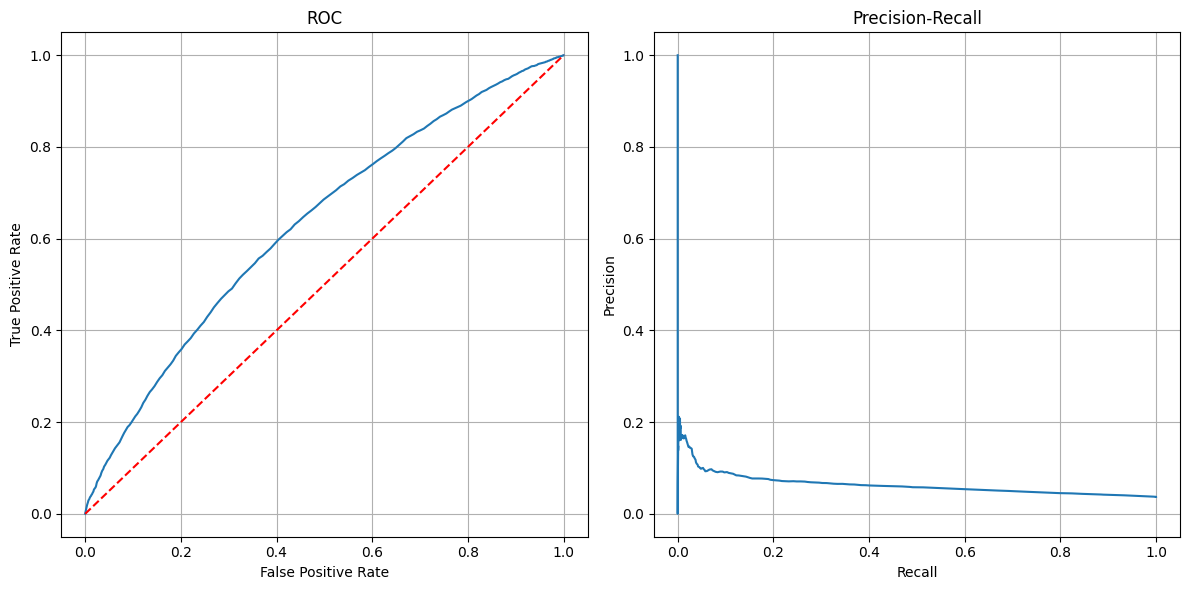

In [35]:
rf = RandomForestClassifier(n_estimators=500, n_jobs=-1)
rf.fit(X_train_processed, y_train_processed)

y_pred_rf = rf.predict(X_test_processed)
y_pred_prob_rf = rf.predict_proba(X_test_processed)[:, 1]

apply_metrics(y_pred_rf, y_test_processed, y_pred_prob_rf, "Random Forest")

Random Forest (without undersampling):
Accuracy: 0.9632
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
ROC-AUC: 0.6146


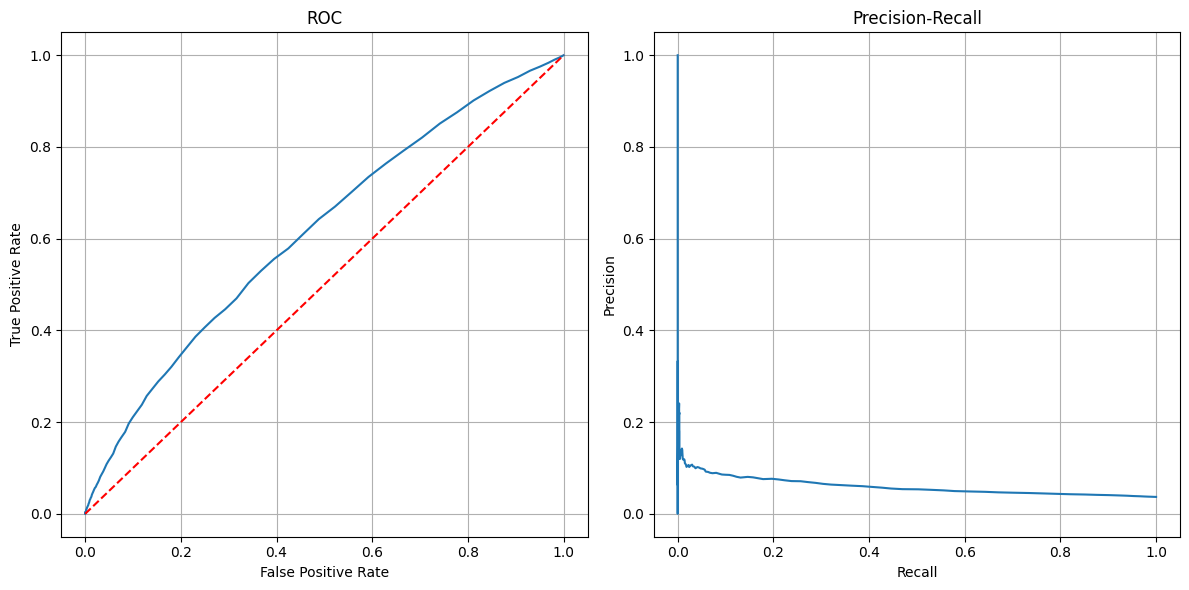

In [36]:
rf2 = RandomForestClassifier(n_estimators=500, n_jobs=-1)
rf2.fit(X_train_base, y_train_base)

y_pred_rf_base = rf2.predict(X_test_base)
y_pred_prob_rf_base = rf2.predict_proba(X_test_base)[:, 1]

apply_metrics(y_pred_rf_base, y_test_base, y_pred_prob_rf_base, "Random Forest (without undersampling)")

## Шаг 5. SVM

Воспользуйтесь `sklearn.svm import SVC`. Сравните с бейзлайном. 

/home/ns/ros2_venv/lib/python3.12/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM:
Accuracy: 0.4158
Precision: 0.0332
Recall: 0.5252
F1-score: 0.0624
ROC-AUC: 0.4558


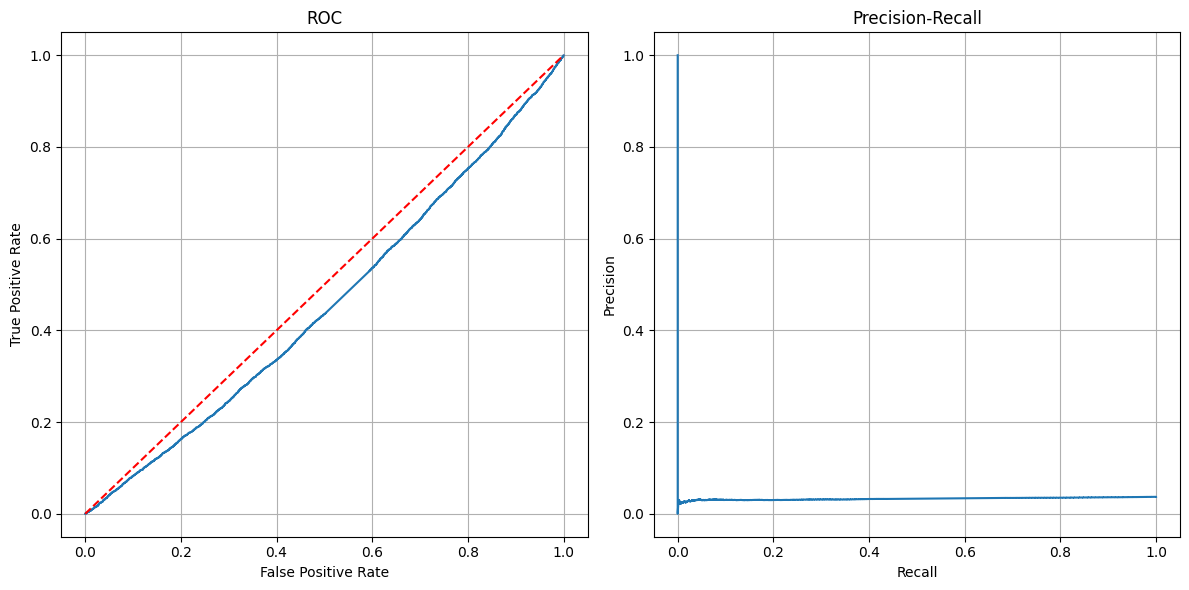

In [37]:
svc = SVC(probability=True, max_iter=1000)  
svc.fit(X_train_processed, y_train_processed)

y_pred_svc = svc.predict(X_test_processed)
y_pred_prob_svc = svc.predict_proba(X_test_processed)[:, 1]

apply_metrics(y_pred_svc, y_test_processed, y_pred_prob_svc, "SVM")

# Задание 4. Ансамблирование

Воспользуйтесь модулем `sklearn.ensemble` для реализации ансамблирования ранее обученных моделей.
Например, вы можете использовать `sklearn.ensemble.VotingClassifier`.
 Сравните с бейзлайном. 

Voting Ensemble:
Accuracy: 0.5529
Precision: 0.0439
Recall: 0.5334
F1-score: 0.0811
ROC-AUC: 0.5892


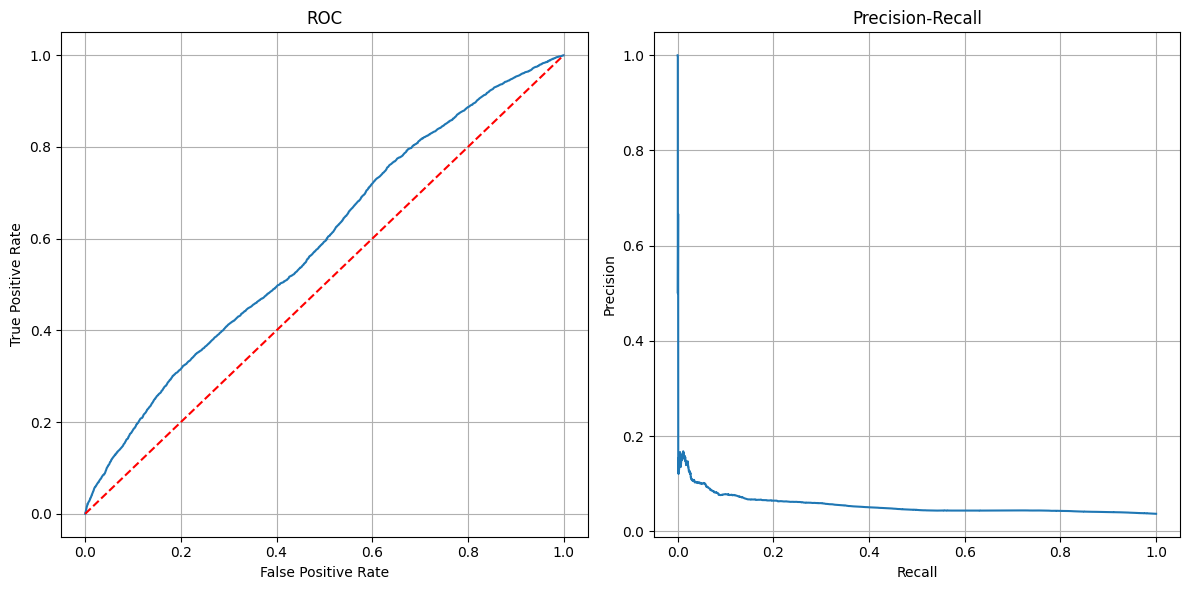

In [39]:
voting_clf = VotingClassifier(
    estimators=[
        ('knn', KNeighborsClassifier(n_neighbors=20, n_jobs=-1)),
        ('dt', DecisionTreeClassifier()),
        ('rf', RandomForestClassifier(n_estimators=500, n_jobs=-1))
    ],
    voting='soft',
    n_jobs=-1,
    weights=[1, 1, 3]
)

voting_clf.fit(X_train_processed, y_train_processed)

y_pred_ens = voting_clf.predict(X_test_processed)
y_pred_prob_ens = voting_clf.predict_proba(X_test_processed)[:, 1]

apply_metrics(y_pred_ens, y_test_processed, y_pred_prob_ens, "Voting Ensemble")

# Дополнительное задание**

Реализуйте в .py модуле (или в нескольких модулях, архитектура остается на ваше усматрение, будьте готовы ее объяснить):
- пайплайн обработки данных (как в задании 1), 
- пайплайн обучения/дообучения ансамбля (как в заданиях 2,3). Также вычислите метрики и выведите их в консоль 
- пайплайн для классификации нового объекта ансамблем моделей (без обучения этих моделей, только предсказание метрик)

